                       bsdb ref_idsys      id     e   q      period        a  \
0  J000001.02-192955.7:p1-2        HD  224690  0.00 NaN  499.798900  0.01431   
1  J000001.02-192955.7:p3-4        HD  224690  0.00 NaN  499.798900  0.01431   
2  J000001.02-192955.7:p3-4       HIP       2  0.00 NaN  499.798900  0.01431   
3  J000001.02-192955.7:p3-4       HIP       2  0.00 NaN  499.798969  0.01431   
4  J000004.08+341118.8:p1-2      SBC9    1707  0.47 NaN  953.000000      NaN   

   parallax       i      catalogue    filename  line  
0       NaN  118.06           ORB6    orb6.dat  4130  
1       NaN  118.06           ORB6    orb6.dat  4133  
2       NaN  118.06           ORB6    orb6.dat  4133  
3     20.85     NaN  J/A+A/546/A69  table1.dat  4133  
4       NaN     NaN            SB9  orbits.dat  4178  


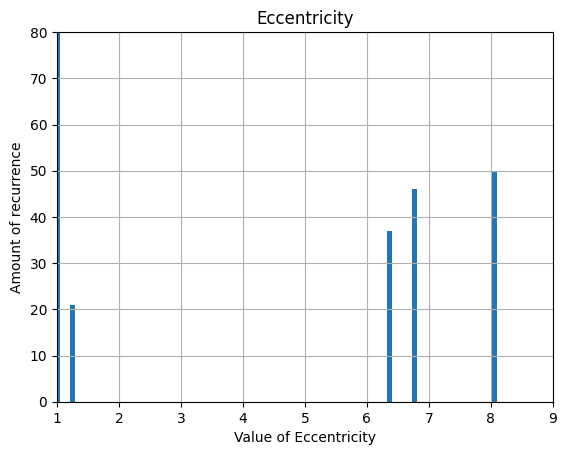

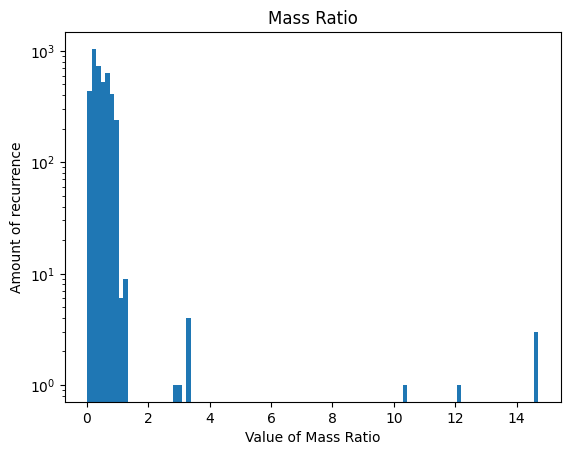

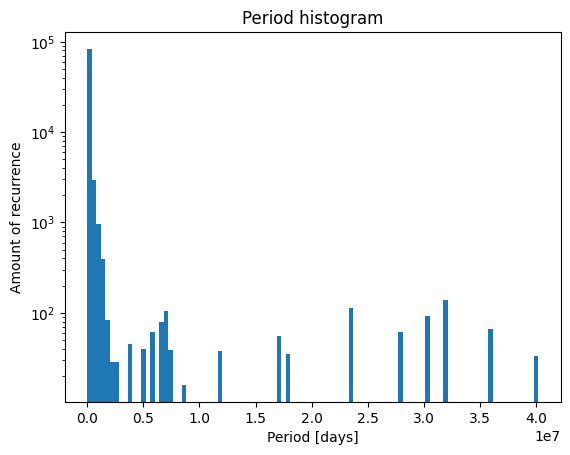

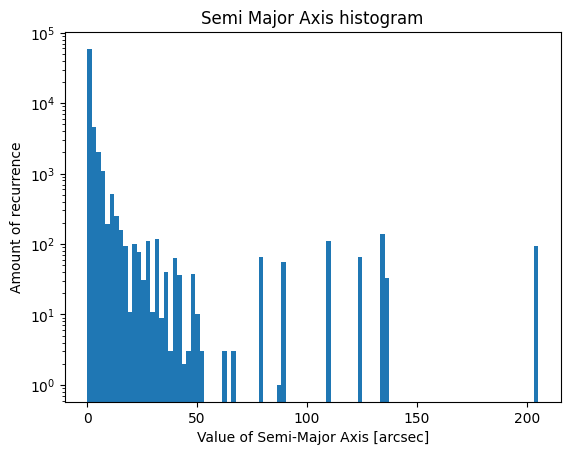

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df = pd.read_csv(r'DATA/RAW/table2.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["bsdb"]
print(df.head())

plt.hist(eccentricity, bins=100)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('Eccentricity')
plt.grid(True)
plt.xlim(1,9)
plt.ylim(0,80)
plt.show()

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of recurrence')
plt.title('Mass Ratio')
plt.show()

plt.hist(period, log=True, bins=100)
plt.xlabel('Period [days]')
plt.ylabel('Amount of recurrence')
plt.title('Period histogram')
plt.show()

plt.hist(semi_major_ax, log=True, bins=100)
plt.xlabel('Value of Semi-Major Axis [arcsec]')
plt.ylabel('Amount of recurrence')
plt.title('Semi Major Axis histogram')
plt.show()

In [24]:
# Columns to average
avg_cols = ['e', 'q', 'period',"a", 'parallax', 'i']

# Group by bsdb ref_id
reduced_df = (
    df.groupby('bsdb', as_index=False)
      .agg({
          'catalogue': lambda x: '; '.join(x.dropna().astype(str).unique()),
          'filename': lambda x: '; '.join(x.dropna().astype(str).unique()),
        "ref_idsys": lambda x: '; '.join(x.dropna().astype(str).unique()),
        "id": lambda x: '; '.join(x.dropna().astype(str).unique()),
          **{col: 'mean' for col in avg_cols}
      })
)

# Combine catalogue + filename into notes column
reduced_df['notes'] = (
    ' | ref_idsys: ' + reduced_df['ref_idsys'].astype(str) +
    ' | id: ' + reduced_df['id'].astype(str) +
    ' | catalogue: ' + reduced_df['catalogue'].astype(str) +
    ' | filename: ' + reduced_df['filename'].astype(str)

)

# Drop temporary columns
reduced_df = reduced_df.drop(columns=['catalogue', 'filename',"ref_idsys"])

# Save to CSV
reduced_df.to_csv('DATA/RAW/reduced_raw_data.csv', index=False)

print("Saved as reduced_raw_data.csv")
print(reduced_df.head())



Saved as reduced_raw_data.csv
                       bsdb                        id      e      q  \
0  J000001.02-192955.7:p1-2                    224690  0.000    NaN   
1  J000001.02-192955.7:p3-4                 224690; 2  0.000    NaN   
2  J000004.08+341118.8:p1-2                      1707  0.473    NaN   
3  J000007.30+184417.0:p1-2                    DM Peg    NaN  0.325   
4  J000019.10-441726.0:p1-2  224750; 25; 00003-4417AB  0.703    NaN   

          period        a   parallax       i  \
0     499.798900  0.01431        NaN  118.06   
1     499.798923  0.01431  20.850000  118.06   
2     954.500000      NaN        NaN     NaN   
3       2.588993      NaN   1.000000   79.00   
4  140292.525000  1.02300  13.070769   75.30   

                                               notes  
0   | ref_idsys: HD | id: 224690 | catalogue: ORB...  
1   | ref_idsys: HD; HIP | id: 224690; 2 | catalo...  
2   | ref_idsys: SBC9 | id: 1707 | catalogue: SB9...  
3   | ref_idsys: GCVS | id: DM Peg

                       bsdb                        id      e      q  \
0  J000001.02-192955.7:p1-2                    224690  0.000    NaN   
1  J000001.02-192955.7:p3-4                 224690; 2  0.000    NaN   
2  J000004.08+341118.8:p1-2                      1707  0.473    NaN   
3  J000007.30+184417.0:p1-2                    DM Peg    NaN  0.325   
4  J000019.10-441726.0:p1-2  224750; 25; 00003-4417AB  0.703    NaN   

          period        a   parallax       i  \
0     499.798900  0.01431        NaN  118.06   
1     499.798923  0.01431  20.850000  118.06   
2     954.500000      NaN        NaN     NaN   
3       2.588993      NaN   1.000000   79.00   
4  140292.525000  1.02300  13.070769   75.30   

                                               notes  
0   | ref_idsys: HD | id: 224690 | catalogue: ORB...  
1   | ref_idsys: HD; HIP | id: 224690; 2 | catalo...  
2   | ref_idsys: SBC9 | id: 1707 | catalogue: SB9...  
3   | ref_idsys: GCVS | id: DM Peg | catalogue: J...  
4   | ref

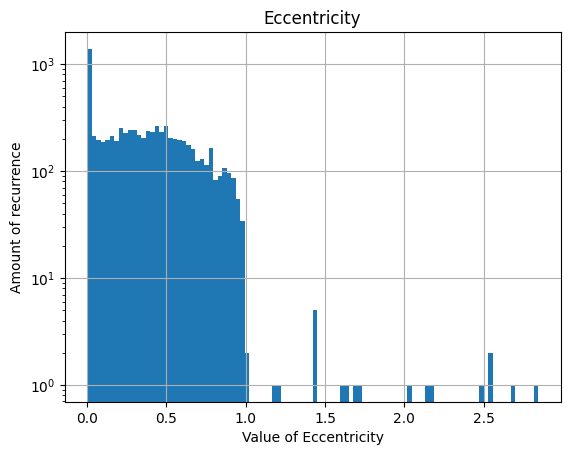

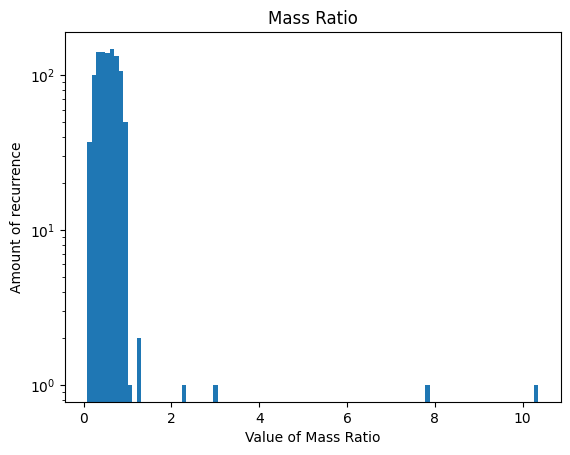

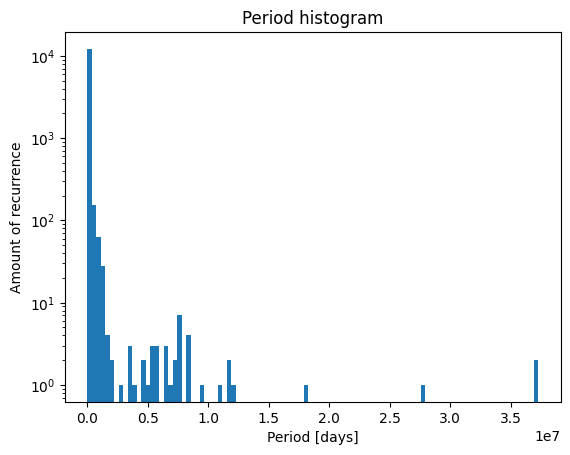

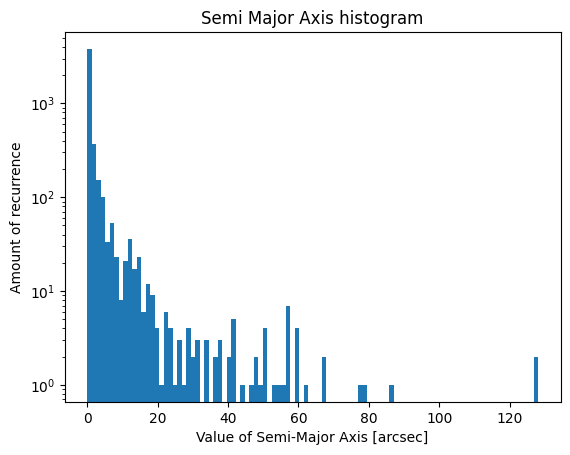

In [27]:
df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["bsdb"]
print(df.head())

plt.hist(eccentricity, log=True, bins=100)
plt.xlabel('Value of Eccentricity')
plt.ylabel('Amount of recurrence')
plt.title('Eccentricity')
plt.grid(True)
plt.show()

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of recurrence')
plt.title('Mass Ratio')
plt.show()

plt.hist(period, log=True, bins=100)
plt.xlabel('Period [days]')
plt.ylabel('Amount of recurrence')
plt.title('Period histogram')
plt.show()

plt.hist(semi_major_ax, log=True, bins=100)
plt.xlabel('Value of Semi-Major Axis [arcsec]')
plt.ylabel('Amount of recurrence')
plt.title('Semi Major Axis histogram')
plt.show()